Using device: cpu
Starting training...
Epoch     0 | Total Loss: 17323.76 | Data Loss: 17323.70
Epoch   500 | Total Loss: 9061.78 | Data Loss: 9061.78
Epoch  1000 | Total Loss: 4868.82 | Data Loss: 4868.82
Epoch  1500 | Total Loss: 2544.82 | Data Loss: 2544.82
Epoch  2000 | Total Loss: 1312.29 | Data Loss: 1312.29
Epoch  2500 | Total Loss: 860.78 | Data Loss: 860.78
Epoch  3000 | Total Loss: 702.22 | Data Loss: 702.22
Epoch  3500 | Total Loss: 674.43 | Data Loss: 674.42
Epoch  4000 | Total Loss: 698.28 | Data Loss: 698.23
Epoch  4500 | Total Loss: 263.59 | Data Loss: 259.94
Epoch  5000 | Total Loss: 142.79 | Data Loss: 129.84
Epoch  5500 | Total Loss: 74.88 | Data Loss: 72.86
Epoch  6000 | Total Loss: 43.20 | Data Loss: 40.36
Epoch  6500 | Total Loss: 28.29 | Data Loss: 25.07
Epoch  7000 | Total Loss: 17.42 | Data Loss: 16.48
Epoch  7500 | Total Loss: 12.70 | Data Loss: 11.32
Epoch  8000 | Total Loss: 12.09 | Data Loss: 8.24
Epoch  8500 | Total Loss: 6.94 | Data Loss: 6.38
Epoch  9000 

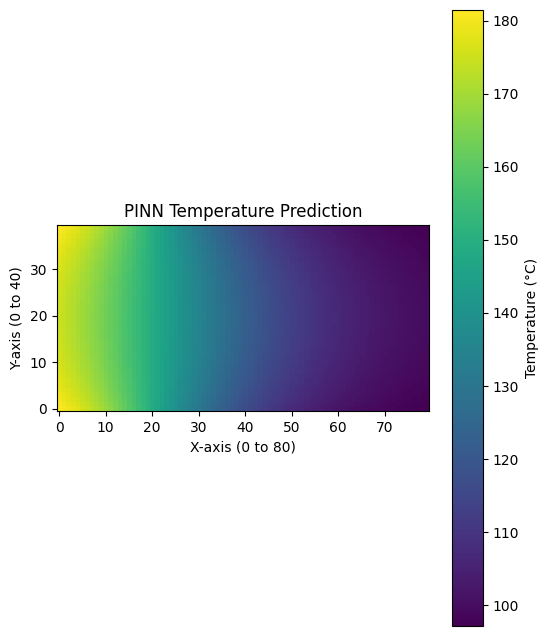

In [2]:
import torch
import torch.nn as nn
import numpy as np
import h5py
import matplotlib.pyplot as plt

# ==========================================
# FIX: LOCK RANDOMNESS (So your graph matches the senior's)
# ==========================================
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. PHYSICS CONSTANTS
# ==========================================
rho = 780.0
cp = 2000.0
k = 0.2
L = 2e5
Tm = 50.0
dT = 2.0

# ==========================================
# 2. LOAD DATA
# ==========================================
file = r"C:\Users\risha\Desktop\pcm_project\pcm_dataset_2D\pcm2D_case_0040.h5"
with h5py.File(file, "r") as f:
    x = f["case/x"][:]
    y = f["case/y"][:]
    times = f["case/times"][:]
    T = f["case/T"][:]

# Get max/min values for scaling
x_max, x_min = x.max(), x.min()
y_max, y_min = y.max(), y.min()
t_max, t_min = times.max(), times.min()

X, Y, TT = np.meshgrid(x, y, times, indexing="ij")
coords = np.stack([X.flatten(), Y.flatten(), TT.flatten()], axis=1)
targets = T.transpose(2,1,0).flatten()

coords = torch.from_numpy(coords).float().to(device)
targets = torch.from_numpy(targets).float().unsqueeze(1).to(device)

# ==========================================
# 3. SENIOR'S FIX #1: SCALE COORDS TO [-1, 1]
# ==========================================
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
2
    def forward(self, xyt):
        # We scale the inputs INSIDE the brain. 
        # This stops the math from exploding, but allows PyTorch 
        # to still automatically handle the physical chain rule!
        x_scaled = 2.0 * (xyt[:, 0:1] - x_min) / (x_max - x_min) - 1.0
        y_scaled = 2.0 * (xyt[:, 1:2] - y_min) / (y_max - y_min) - 1.0
        t_scaled = 2.0 * (xyt[:, 2:3] - t_min) / (t_max - t_min) - 1.0
        
        scaled_inputs = torch.cat([x_scaled, y_scaled, t_scaled], dim=1)
        return self.network(scaled_inputs)

model = PINN().to(device)

# ==========================================
# 4. PHYSICS ENGINE
# ==========================================
def df_dT(T):
    Ts = Tm - dT
    Tl = Tm + dT
    mask = (T > Ts) & (T < Tl)
    df = torch.zeros_like(T)
    xi = (T - Ts)/(2*dT)
    df[mask] = (6*xi[mask] - 6*xi[mask]**2)/(2*dT)
    return df

def pde_residual(model, xyt):
    xyt.requires_grad_(True)
    T_pred = model(xyt)

    grads = torch.autograd.grad(T_pred, xyt, torch.ones_like(T_pred), create_graph=True)[0]
    Tx = grads[:, 0:1]
    Ty = grads[:, 1:2]
    Tt = grads[:, 2:3]

    Txx = torch.autograd.grad(Tx, xyt, torch.ones_like(Tx), create_graph=True)[0][:, 0:1]
    Tyy = torch.autograd.grad(Ty, xyt, torch.ones_like(Ty), create_graph=True)[0][:, 1:2]

    ceff = cp + L * df_dT(T_pred)
    residual = rho * ceff * Tt - k * (Txx + Tyy)
    return residual

# ==========================================
# 5. SENIOR'S FIX #2: CHANGE LOSS FUNCTION
# ==========================================
def loss_function(model, coords, targets):
    pred = model(coords)
    data_loss = torch.mean((pred - targets)**2)
    
    res = pde_residual(model, coords)
    physics_loss = torch.mean(res**2)

    # Adding a weight of 1e-6 so the Latent Heat stops bullying the Data Grade
    w_physics = 1e-6 
    loss = data_loss + (w_physics * physics_loss)
    
    return loss, data_loss, physics_loss

# ==========================================
# 6. SENIOR'S FIX #3: INCREASE EPOCHS
# ==========================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Increased to 10,000 as requested by the senior for more defined results
epochs = 10000 
batch_size = 4096
N = coords.shape[0]

print("Starting training...")
for epoch in range(epochs):
    idx = torch.randperm(N)[:batch_size]
    batch_coords = coords[idx]
    batch_targets = targets[idx]

    optimizer.zero_grad()
    
    loss, d_loss, p_loss = loss_function(model, batch_coords, batch_targets)

    loss.backward()
    optimizer.step()

    # Print every 500 epochs to keep the screen clean
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total Loss: {loss.item():.2f} | Data Loss: {d_loss.item():.2f}")

# ==========================================
# 7. VISUALIZE RESULTS (Fixed Plotting)
# ==========================================
with torch.no_grad():
    T_pred = model(coords).cpu().numpy()

T_pred = T_pred.reshape(len(x), len(y), len(times))

plt.figure(figsize=(6, 8))
# .T ensures it plots X on the bottom and Y on the side properly
plt.imshow(T_pred[:, :, -1].T, origin='lower', cmap='viridis')
plt.colorbar(label="Temperature (°C)")
plt.title("PINN Temperature Prediction")
plt.xlabel("X-axis (0 to 80)")
plt.ylabel("Y-axis (0 to 40)")
plt.show()

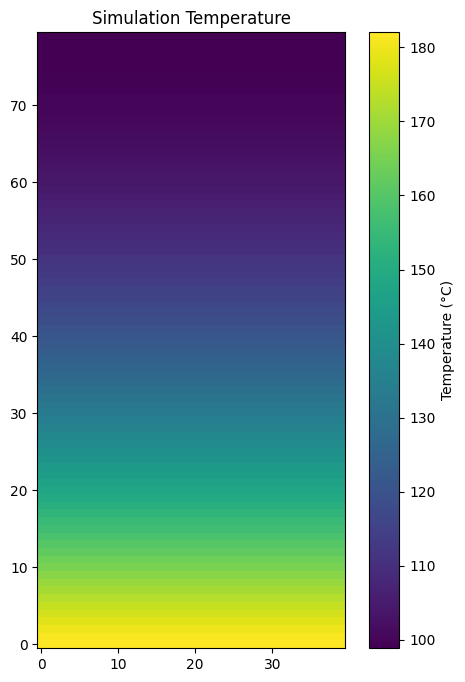

In [3]:
plt.figure(figsize=(6,8))
plt.imshow(T[-1].T, origin="lower", cmap="viridis")
plt.colorbar(label="Temperature (°C)")
plt.title("Simulation Temperature")
plt.show()

In [4]:
print("Dataset temperature range:", T.min(), T.max())

Dataset temperature range: 98.86309820748387 182.0293323170122
